# SalesPilot — Data Loading Pipeline

Loads all 4 CRM CSVs (accounts, products, sales_teams, sales_pipeline),
normalises columns, resolves foreign keys, and explores the data before DB load.

In [1]:
import sys, os
# Add project root so app.* imports work
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

CSV_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
print(f"Project root: {PROJECT_ROOT}")
print(f"CSV dir: {CSV_DIR}")

Project root: /Users/kanakasarat/Downloads/CRM+Sales+Opportunities/salespilot
CSV dir: /Users/kanakasarat/Downloads/CRM+Sales+Opportunities/salespilot/data/raw


## 1. Load & Transform CSVs

In [2]:
from pathlib import Path
from app.data.data_loader import (
    _load_accounts, _load_products, _load_sales_teams, _load_opportunities
)

csv_path = Path(CSV_DIR)

acct_df = _load_accounts(csv_path)
prod_df = _load_products(csv_path)
team_df = _load_sales_teams(csv_path)

print(f"Accounts:    {acct_df.shape}")
print(f"Products:    {prod_df.shape}")
print(f"Sales Teams: {team_df.shape}")

Accounts:    (85, 10)
Products:    (7, 4)
Sales Teams: (35, 4)


In [3]:
acct_df.head(10)

,account_id,account_name,industry,company_size,revenue,year_established,region,subsidiary_of,latitude,longitude
0,8836431947471538,Acme Corporation,technolgy,2822,1100.04,1996,United States,NaN,37.325009,-121.893420
1,5745241362957565,Betasoloin,medical,495,251.41,1999,United States,NaN,37.370005,-121.869358
2,5110844135380882,Betatech,medical,1185,647.18,1986,Kenya,NaN,33.483532,-112.057449
3,7143654564919261,Bioholding,medical,1356,587.34,2012,Philipines,NaN,36.151433,-115.131821
4,4253168845593269,Bioplex,medical,1016,326.82,1991,United States,NaN,37.291059,-121.935246
5,4397449467165315,Blackzim,retail,1588,497.11,2009,United States,NaN,37.369444,-121.918372
6,523088265998795,Bluth Company,technolgy,3027,1242.32,1993,United States,Acme Corporation,37.373508,-121.874269
7,2890348863430312,Bubba Gump,software,2253,987.39,2002,United States,NaN,37.349833,-121.880933
8,3231857028390948,Cancity,retail,2448,718.62,2001,United States,NaN,37.365354,-121.839669
9,1692448631705585,Cheers,entertainment,6472,4269.90,1993,United States,Massive Dynamic,37.324996,-121.868918


In [4]:
prod_df

,product_id,product_name,series,sales_price
0,4471905713638513,GTX Basic,GTX,550
1,3414315153195358,GTX Pro,GTX,4821
2,5099918575789089,MG Special,MG,55
3,5638643524741746,MG Advanced,MG,3393
4,3680937203832730,GTX Plus Pro,GTX,5482
5,8800795766140891,GTX Plus Basic,GTX,1096
6,384964481132582,GTK 500,GTK,26768


In [5]:
team_df.head(10)

,agent_id,sales_agent,manager,regional_office
0,8692575427864550,Anna Snelling,Dustin Brinkmann,Central
1,558647770120855,Cecily Lampkin,Dustin Brinkmann,Central
2,4858364972403035,Versie Hillebrand,Dustin Brinkmann,Central
3,7104627639449506,Lajuana Vencill,Dustin Brinkmann,Central
4,4950957932798709,Moses Frase,Dustin Brinkmann,Central
5,6685983818931176,Jonathan Berthelot,Melvin Marxen,Central
6,6413802397053573,Marty Freudenburg,Melvin Marxen,Central
7,5234651888769761,Gladys Colclough,Melvin Marxen,Central
8,3051977947683807,Niesha Huffines,Melvin Marxen,Central
9,7971625204640674,Darcel Schlecht,Melvin Marxen,Central


## 2. Build FK Lookups & Load Opportunities

In [6]:
# Build lookup dicts (lowercase name -> id)
account_lookup = dict(zip(
    acct_df["account_name"].str.strip().str.lower(),
    acct_df["account_id"],
))
agent_lookup = dict(zip(
    team_df["sales_agent"].str.strip().str.lower(),
    team_df["agent_id"],
))
product_lookup = dict(zip(
    prod_df["product_name"].str.strip().str.lower(),
    prod_df["product_id"],
))

opp_df = _load_opportunities(csv_path, account_lookup, agent_lookup, product_lookup)
print(f"Opportunities: {opp_df.shape}")
opp_df.head(10)

Opportunities: (7375, 10)


,opportunity_id,account_id,agent_id,product_id,deal_value,sales_stage,engage_date,close_date,days_since_last_contact,deal_closed
0,3385693789861965,3231857028390948,4950957932798709,8800795766140891,1054.0,Won,2016-10-20,2017-03-01,3298,1
1,4288615006457101,1268475830787827,7971625204640674,<NA>,4514.0,Won,2016-10-25,2017-03-11,3288,1
2,4816390175053609,3231857028390948,7971625204640674,5099918575789089,50.0,Won,2016-10-25,2017-03-07,3292,1
3,7143232003420526,1728115136939395,4950957932798709,4471905713638513,588.0,Won,2016-10-25,2017-03-09,3290,1
4,3766527038648061,2318883451980450,4256506655091195,4471905713638513,517.0,Won,2016-10-25,2017-03-02,3297,1
5,4565613480193127,7060784304006836,8692575427864550,5099918575789089,49.0,Won,2016-10-29,2017-03-01,3298,1
6,1807830857365098,1155161566462727,2955250473856060,5099918575789089,57.0,Won,2016-10-30,2017-03-02,3297,1
7,2812187742509932,1692448631705585,5833584249664034,4471905713638513,601.0,Won,2016-11-01,2017-03-07,3292,1
8,1020254579161978,3875033918043451,3051977947683807,8800795766140891,1026.0,Won,2016-11-01,2017-03-03,3296,1
10,1796677289935374,7143654564919261,8692575427864550,5099918575789089,53.0,Won,2016-11-04,2017-03-10,3289,1


## 3. Quick EDA

In [7]:
print("=== Accounts ===")
print(f"Unique industries: {acct_df['industry'].nunique()}")
print(f"Regions: {acct_df['region'].unique().tolist()}")
print(f"Company size range: {acct_df['company_size'].min()} - {acct_df['company_size'].max()}")
print(f"Revenue range: ${acct_df['revenue'].min():.1f}M - ${acct_df['revenue'].max():.1f}M")
print()

print("=== Opportunities ===")
print(f"Total deals: {len(opp_df):,}")
print(f"Deal stages: {opp_df['sales_stage'].value_counts().to_dict()}")
print(f"Win rate: {opp_df['deal_closed'].mean():.1%}")
print(f"Avg deal value: ${opp_df['deal_value'].mean():,.0f}")
print(f"FK coverage — agent_id null: {opp_df['agent_id'].isna().sum()}, product_id null: {opp_df['product_id'].isna().sum()}")

=== Accounts ===
Unique industries: 10
Regions: ['United States', 'Kenya', 'Philipines', 'Japan', 'Italy', 'Norway', 'Korea', 'Jordan', 'Brazil', 'Germany', 'Panama', 'Belgium', 'Romania', 'Poland', 'China']
Company size range: 9 - 34288
Revenue range: $4.5M - $11698.0M

=== Opportunities ===
Total deals: 7,375
Deal stages: {'Won': 4238, 'Lost': 2473, 'Engaging': 501, 'Prospecting': 163}
Win rate: 57.5%
Avg deal value: $1,357
FK coverage — agent_id null: 0, product_id null: 1258


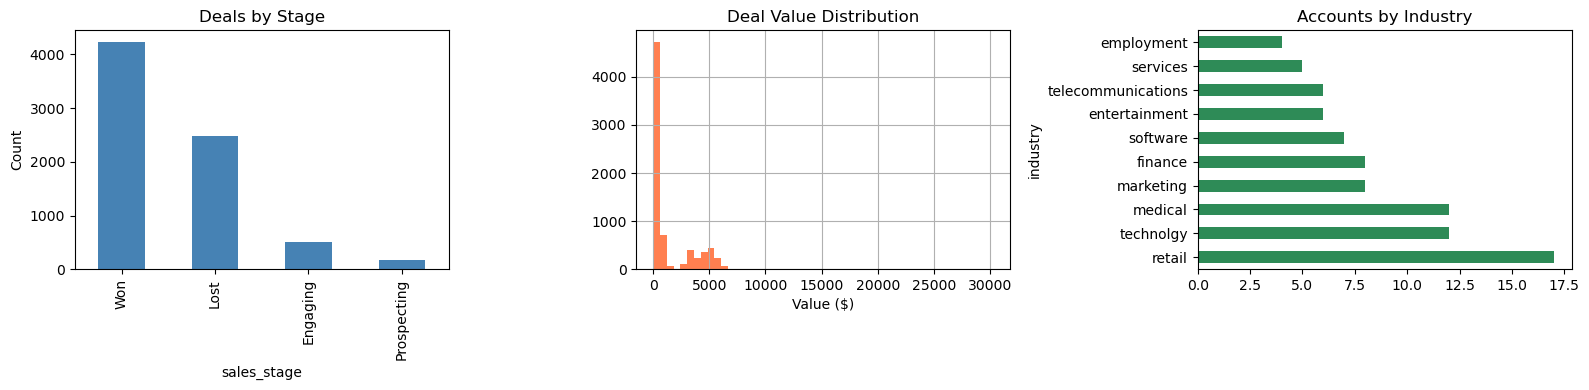

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Deal stage distribution
opp_df["sales_stage"].value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Deals by Stage")
axes[0].set_ylabel("Count")

# Deal value distribution
opp_df["deal_value"].hist(bins=50, ax=axes[1], color="coral")
axes[1].set_title("Deal Value Distribution")
axes[1].set_xlabel("Value ($)")

# Industry breakdown
acct_df["industry"].value_counts().plot.barh(ax=axes[2], color="seagreen")
axes[2].set_title("Accounts by Industry")

plt.tight_layout()
plt.show()

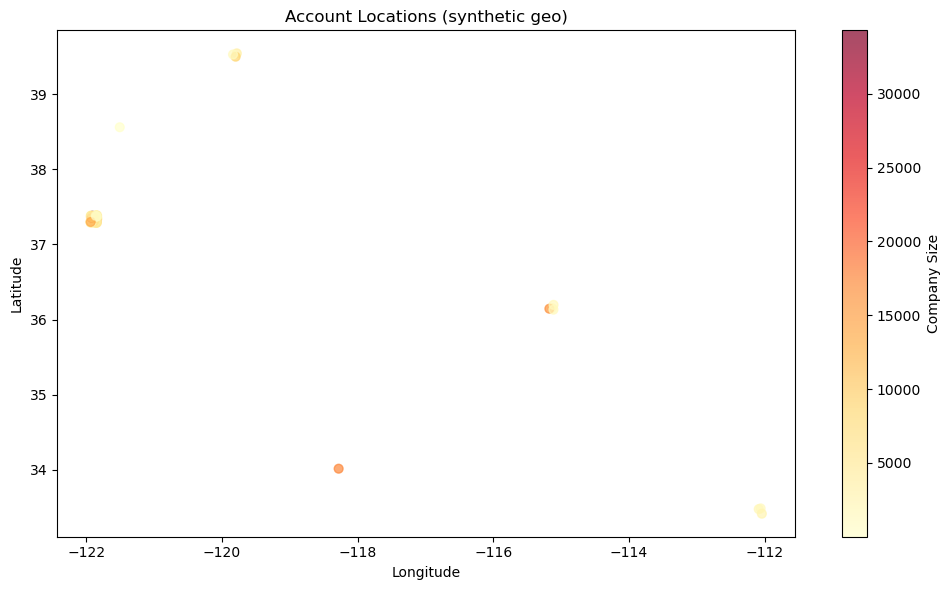

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    acct_df["longitude"], acct_df["latitude"],
    c=acct_df["company_size"], cmap="YlOrRd", s=40, alpha=0.7
)
plt.colorbar(scatter, label="Company Size")
ax.set_title("Account Locations (synthetic geo)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 4. Load into PostgreSQL

Requires a running PostgreSQL instance (see `docker-compose.yml`).
Skip this section if you just want to explore the data locally.

In [10]:
from app.data.data_loader import load_csv

counts = load_csv(CSV_DIR)
counts

OperationalError: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: FATAL:  role "salespilot" does not exist

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [11]:
import pandas as pd
from app.db.session import engine

for table in ["accounts", "products", "sales_teams", "opportunities"]:
    df = pd.read_sql(f"SELECT COUNT(*) AS cnt FROM {table}", engine)
    print(f"{table:20s} → {df['cnt'].iloc[0]:,} rows")

OperationalError: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: FATAL:  role "salespilot" does not exist

(Background on this error at: https://sqlalche.me/e/20/e3q8)